# FFNN outer - development

In [17]:
from paths import *
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

## Collect multiple PFI
Function to collect and return highest pairwise attr across models (runs)

In [18]:
total_interaction_pairs_df = pd.DataFrame()
for r_num in range(96, 99):
    print(f"Run number: run{r_num}")
    top_interaction_pairs_path = os.path.join(path_to_nn_runs, f"torch_mlp_n400_k12_standard_run{r_num}/","top_interaction_pair_kmers.csv")
    top_interaction_pairs_df = pd.read_csv(top_interaction_pairs_path)
    total_interaction_pairs_df = pd.concat([total_interaction_pairs_df, top_interaction_pairs_df], ignore_index=True)
display(total_interaction_pairs_df)

Run number: run96
Run number: run97
Run number: run98


,feature_index,entity,organism,decoded_kmer
0,5,J96_22_reoriented,bacterium,TAACATACGATC
1,104,J96_22_reoriented,bacterium,GAAGCCACAATG
2,143,J96_22_reoriented,bacterium,AAATTGACATTC
3,190,J96_22_reoriented,bacterium,TAACAGAATTTG
4,315,J96_22_reoriented,bacterium,CTTGTGCTTTTT
...,...,...,...,...
148,3160,J96_22_reoriented,bacterium,TTTGTCCGCGTT
149,3188,J96_22_reoriented,bacterium,GCGCCAACTGCG
150,3189,J96_22_reoriented,bacterium,CTATTGGGTTAA
151,3255,J96_22_reoriented,bacterium,CCTACACCCGGC


,decoded_kmer,abundance
0,TAACATACGATC,3
1,GAAGCCACAATG,3
2,AAATTGACATTC,3
3,TAACAGAATTTG,3
4,CTTGTGCTTTTT,3
5,GCGTCGCACCCG,3
6,AAACCCGATGGC,3
7,TGGGGCACTTTC,3
8,TCTCAGTTCTGG,3
9,GGAATAAAGCTT,3


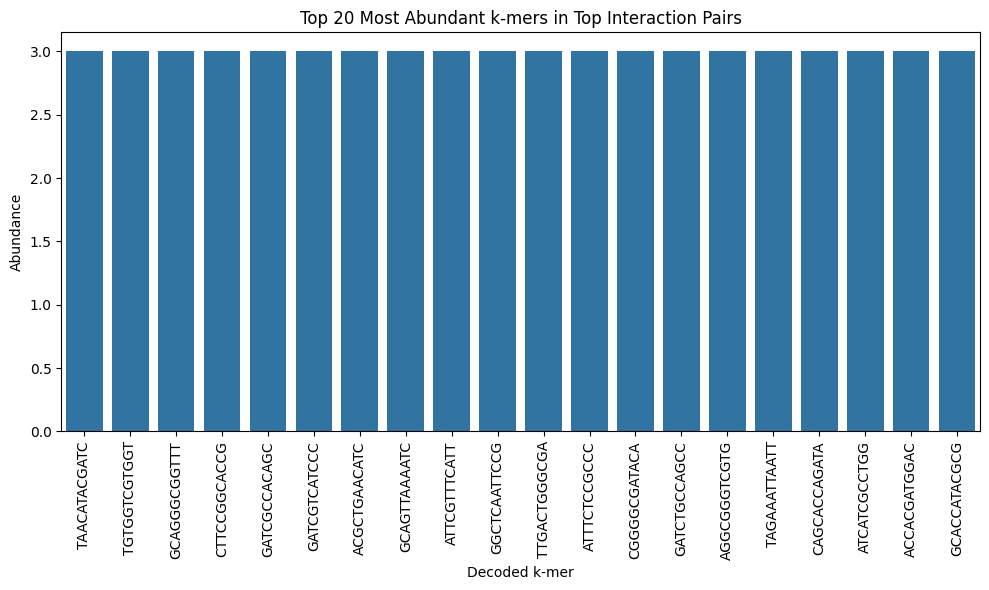

In [19]:
from collections import Counter
kmer_abundance = Counter(total_interaction_pairs_df['decoded_kmer'].tolist())
kmer_abundance_df = pd.DataFrame(kmer_abundance.items(), columns=['decoded_kmer', 'abundance'])
display(kmer_abundance_df)

plt.figure(figsize=(10, 6))
sns.barplot(x='decoded_kmer', y='abundance', data=kmer_abundance_df.sort_values(by='abundance', ascending=False).head(20))
plt.xticks(rotation=90)
plt.title('Top 20 Most Abundant k-mers in Top Interaction Pairs')
plt.xlabel('Decoded k-mer')
plt.ylabel('Abundance')
plt.tight_layout()
plt.show()

In [ ]:
outdir = "pfi_interaction_kmers_analysis/"
if not os.path.exists(outdir):
    os.makedirs(outdir)

# Aggregate total_interaction_pairs_df by combining "decoded_kmer" column, and recreating the other columns into a list of unique values for each "decoded_kmer"
total_aggr_df = total_interaction_pairs_df.groupby('decoded_kmer').agg({
    'feature_index': lambda x: list(set(x)),
    'entity': lambda x: list(set(x)),
    'organism': lambda x: list(set(x))
}).reset_index()

display(total_aggr_df)
#total_aggr_df.to_csv(outdir+"top_interaction_kmers_aggregated.csv", index=False)

,decoded_kmer,feature_index,entity,organism
0,AAACCCGATGGC,[405],[J96_22_reoriented],[bacterium]
1,AAATTGACATTC,[143],[J96_22_reoriented],[bacterium]
2,AAGAGCGCTGTT,[1317],[J96_22_reoriented],[bacterium]
3,AATATGCAGGTC,[574],[J96_22_reoriented],[bacterium]
4,ACCACGATGGAC,[3076],[J96_22_reoriented],[bacterium]
5,ACGCTGAACATC,[2342],[J96_22_reoriented],[bacterium]
6,AGATCCATGTTG,[1763],[J96_22_reoriented],[bacterium]
7,AGGACTACATGA,[556],[J96_22_reoriented],[bacterium]
8,AGGCGGGTCGTG,[2918],[J96_22_reoriented],[bacterium]
9,ATACTTATGTCC,[691],[J96_22_reoriented],[bacterium]


## Annotate genomes
Function to annotate genomes with protein names

### Using Empathi
Embedding-based Phage Protein Annotation Tool by Hierarchical Assignment - https://www.nature.com/articles/s41467-025-64177-5

## Map Kmers to Protein name
Function to map kmer to location in genome, outputting annotated protein it's part of.\
input: top_interaction_pair_kmers.csv from each run